# Freshness Classification — VGG16 Training (Google Colab)

**Before running:** Runtime → Change runtime type → Hardware accelerator → GPU (T4)

Upload your `Dataset` folder (train/val/test, each with fresh/rotten subfolders) to Google Drive first, then update `DRIVE_DATASET_PATH` below to match.

In [1]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1) Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!mkdir -p /content/Dataset
!mkdir -p /content/Dataset/train
!mkdir -p /content/Dataset/test
!mkdir -p /content/Dataset/val

In [4]:
!cp -r "/content/drive/MyDrive/Colab Notebooks/Dataset/test/fresh" /content/Dataset/test
print("done")
!cp -r "/content/drive/MyDrive/Colab Notebooks/Dataset/test/rotten" /content/Dataset/test
print("done")

done
done


In [10]:
# !rm -rf /content/Dataset/train/fresh
!rm -rf /content/Dataset/train/rotten
# !rm -rf /content/Dataset/val/fresh
# !rm -rf /content/Dataset/val/rotten

In [6]:
!cp -r "/content/drive/MyDrive/Colab Notebooks/Dataset/train/fresh" /content/Dataset/train
print("done")

done


In [11]:
!cp -r "/content/drive/MyDrive/Colab Notebooks/Dataset/train/rotten" /content/Dataset/train
print("done")

done


In [12]:
!cp -r "/content/drive/MyDrive/Colab Notebooks/Dataset/val/fresh" /content/Dataset/val
print("done")
!cp -r "/content/drive/MyDrive/Colab Notebooks/Dataset/val/rotten" /content/Dataset/val
print("done")

done
done


## 2) Config — paths and hyperparameters

Update `DRIVE_DATASET_PATH` to wherever you uploaded the `Dataset` folder in your Drive.
Example: if you uploaded the whole project folder to `My Drive/Freshness classification of Fruits or Vegetables using YOLOv8s and VGG16`, the path below already matches that.

In [24]:
import os

PROJECT_ROOT = "/content"
DRIVE_DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks"

DATASET_DIR = os.path.join(PROJECT_ROOT, "Dataset")
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR   = os.path.join(DATASET_DIR, "val")
TEST_DIR  = os.path.join(DATASET_DIR, "test")

LOCAL_DIR = "/content/checkpoints"
os.makedirs(LOCAL_DIR, exist_ok=True)
LOCAL_CKPT_STAGE1 = os.path.join(LOCAL_DIR, "latest_stage1.keras")
LOCAL_CKPT_STAGE2 = os.path.join(LOCAL_DIR, "latest_stage2.keras")

MODELS_DIR = os.path.join(DRIVE_DATASET_PATH, "Models")
os.makedirs(MODELS_DIR, exist_ok=True)
HISTORY_PATH_STAGE1 = os.path.join(MODELS_DIR, "history_stage1.json")
HISTORY_PATH_STAGE2 = os.path.join(MODELS_DIR, "history_stage2.json")

MODEL_OUT = os.path.join(MODELS_DIR, "freshness_vgg16.keras")              # best model (by val_accuracy)
LATEST_CKPT_STAGE1 = os.path.join(MODELS_DIR, "latest_stage1.keras")       # synced copy on Drive, stage 1
LATEST_CKPT_STAGE2 = os.path.join(MODELS_DIR, "latest_stage2.keras")       # synced copy on Drive, stage 2

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_STAGE1 = 12
EPOCHS_STAGE2 = 6

print("Train dir:", TRAIN_DIR, "-> exists:", os.path.exists(TRAIN_DIR))
print("Val dir  :", VAL_DIR, "-> exists:", os.path.exists(VAL_DIR))
print("Test dir :", TEST_DIR, "-> exists:", os.path.exists(TEST_DIR))
print("Model will be saved to:", MODEL_OUT)
EPOCH_LOG_STAGE1 = os.path.join(MODELS_DIR, "epoch_count_stage1.txt")
EPOCH_LOG_STAGE2 = os.path.join(MODELS_DIR, "epoch_count_stage2.txt")


Train dir: /content/Dataset/train -> exists: True
Val dir  : /content/Dataset/val -> exists: True
Test dir : /content/Dataset/test -> exists: True
Model will be saved to: /content/drive/MyDrive/Colab Notebooks/Models/freshness_vgg16.keras


RESUME_STAGE = None  # set to 1 or 2 if resuming after a disconnect
resumed_model = None
initial_epoch_stage1 = 0
initial_epoch_stage2 = 0

if RESUME_STAGE == 1 and os.path.exists(LATEST_CKPT_STAGE1):
    from tensorflow.keras.models import load_model
    resumed_model = load_model(LATEST_CKPT_STAGE1, compile=False)
    if os.path.exists(EPOCH_LOG_STAGE1):
        initial_epoch_stage1 = int(open(EPOCH_LOG_STAGE1).read().strip())
    print(f"Resuming Stage 1 from {LATEST_CKPT_STAGE1} at epoch {initial_epoch_stage1}")
elif RESUME_STAGE == 2:
    from tensorflow.keras.models import load_model
    ckpt = LATEST_CKPT_STAGE2 if os.path.exists(LATEST_CKPT_STAGE2) else LATEST_CKPT_STAGE1
    resumed_model = load_model(ckpt, compile=False)
    if os.path.exists(EPOCH_LOG_STAGE2):
        initial_epoch_stage2 = int(open(EPOCH_LOG_STAGE2).read().strip())
    print(f"Resuming Stage 2 from {ckpt} at epoch {initial_epoch_stage2}")
else:
    print("No resume requested - will build a fresh model in the next cells.")

In [35]:
RESUME_STAGE = 2  # set to 1 or 2 if resuming after a disconnect
resumed_model = None
initial_epoch_stage1 = 0
initial_epoch_stage2 = 0

if RESUME_STAGE == 1 and os.path.exists(LATEST_CKPT_STAGE1):
    from tensorflow.keras.models import load_model
    resumed_model = load_model(LATEST_CKPT_STAGE1, compile=False)
    if os.path.exists(EPOCH_LOG_STAGE1):
        initial_epoch_stage1 = int(open(EPOCH_LOG_STAGE1).read().strip())
    print(f"Resuming Stage 1 from {LATEST_CKPT_STAGE1} at epoch {initial_epoch_stage1}")
elif RESUME_STAGE == 2:
    from tensorflow.keras.models import load_model
    ckpt = LATEST_CKPT_STAGE2 if os.path.exists(LATEST_CKPT_STAGE2) else LATEST_CKPT_STAGE1
    resumed_model = load_model(ckpt, compile=False)
    if os.path.exists(EPOCH_LOG_STAGE2):
        initial_epoch_stage2 = int(open(EPOCH_LOG_STAGE2).read().strip())
    print(f"Resuming Stage 2 from {ckpt} at epoch {initial_epoch_stage2}")
else:
    print("No resume requested - will build a fresh model in the next cells.")

Resuming Stage 2 from /content/drive/MyDrive/Colab Notebooks/Models/latest_stage1.keras at epoch 0


## 2c) Disconnect-safe checkpoint helper

Saves locally to `/content/checkpoints` every epoch (fast, reliable), then copies to Drive. This avoids the Drive FUSE mount silently lagging or failing on every-epoch writes of a large file.

In [27]:
import shutil
from tensorflow.keras.callbacks import Callback

class DriveSyncCheckpoint(Callback):
    """Saves to local disk every epoch, then copies to Drive. Prints a confirmation so silent failures are visible."""
    def __init__(self, local_path, drive_path):
        super().__init__()
        self.local_path = local_path
        self.drive_path = drive_path

    def on_epoch_end(self, epoch, logs=None):
        try:
            self.model.save(self.local_path)
            shutil.copy(self.local_path, self.drive_path)
            print(f"  [checkpoint] saved epoch {epoch+1} -> {self.drive_path}")
        except Exception as e:
            print(f"  [checkpoint] WARNING: failed to save/copy checkpoint: {e}")

## 3) Imports

In [28]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

## 4) Data generators
`classes=["fresh", "rotten"]` forces fresh=0, rotten=1 consistently — must match your inference script.

In [29]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    classes=["fresh", "rotten"],
    shuffle=True,
)

val_data = val_gen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    classes=["fresh", "rotten"],
    shuffle=False,
)

print("Class indices:", train_data.class_indices)  # expect {'fresh': 0, 'rotten': 1}

Found 57000 images belonging to 2 classes.
Found 9935 images belonging to 2 classes.
Class indices: {'fresh': 0, 'rotten': 1}


## 5) Build model — VGG16 backbone + classifier head

In [30]:
from tensorflow.keras.callbacks import Callback

class EpochLogger(Callback):
    """Writes the next epoch index to resume from, so a disconnect doesn't restart epoch counting."""
    def __init__(self, log_path):
        super().__init__()
        self.log_path = log_path

    def on_epoch_end(self, epoch, logs=None):
        with open(self.log_path, "w") as f:
            f.write(str(epoch + 1))

In [31]:
if resumed_model is not None and RESUME_STAGE == 1:
    model = resumed_model
    base = model.layers[0]
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    print("Using resumed Stage 1 model - recompiled, skipping fresh model build.")
else:
    base = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    base.trainable = False  # freeze for stage 1

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

model.summary()

Using resumed Stage 1 model - recompiled, skipping fresh model build.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 132,097 (516.00 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

## 6) Callbacks — early stopping, best-model checkpoint, LR scheduling

In [32]:
import json
from tensorflow.keras.callbacks import Callback

class EpochLogger(Callback):
    """Writes completed epoch count so resume starts from correct epoch."""
    def __init__(self, log_path):
        super().__init__()
        self.log_path = log_path

    def on_epoch_end(self, epoch, logs=None):
        with open(self.log_path, "w") as f:
            f.write(str(epoch + 1))


class HistorySaver(Callback):
    """Appends metrics to a JSON file after every epoch — survives disconnects."""
    def __init__(self, save_path):
        super().__init__()
        self.save_path = save_path
        self.history = {}
        # load existing history if resuming
        if os.path.exists(save_path):
            with open(save_path, "r") as f:
                self.history = json.load(f)

    def on_epoch_end(self, epoch, logs=None):
        if logs:
            for k, v in logs.items():
                self.history.setdefault(k, []).append(float(v))
        with open(self.save_path, "w") as f:
            json.dump(self.history, f, indent=2)

In [33]:
cbs_stage1 = [
    callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    callbacks.ModelCheckpoint(MODEL_OUT, monitor="val_accuracy", save_best_only=True),
    callbacks.ModelCheckpoint(LATEST_CKPT_STAGE1, save_best_only=False),  # overwritten every epoch - disconnect-safe
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7),
    EpochLogger(EPOCH_LOG_STAGE1),
    HistorySaver(HISTORY_PATH_STAGE1),
]

## 7) Stage 1 — train classifier head only (VGG16 frozen)
On a T4 GPU this should run in roughly 1-3 minutes per epoch instead of ~80 minutes on CPU.

In [34]:
history_stage1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_STAGE1,
    initial_epoch=initial_epoch_stage1,
    callbacks=cbs_stage1,
)

## 8) Stage 2 — fine-tune last conv block (block5) of VGG16

In [36]:
if resumed_model is not None and RESUME_STAGE == 2:
    model = resumed_model
    base = model.layers[0]
    print("Using resumed Stage 2 model - continuing fine-tuning.")

base.trainable = True
for layer in base.layers:
    if not layer.name.startswith("block5"):
        layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

cbs_stage2 = [
    callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    callbacks.ModelCheckpoint(MODEL_OUT, monitor="val_accuracy", save_best_only=True),
    callbacks.ModelCheckpoint(LATEST_CKPT_STAGE2, save_best_only=False),  # overwritten every epoch - disconnect-safe
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7),
    EpochLogger(EPOCH_LOG_STAGE2),
    HistorySaver(HISTORY_PATH_STAGE2),
]

history_stage2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_STAGE2,
    initial_epoch=initial_epoch_stage2,
    callbacks=cbs_stage2,
)

Using resumed Stage 2 model - continuing fine-tuning.
Epoch 1/6
 678/1782 ━━━━━━━━━━━━━━━━━━━━ 12:18 669ms/step - accuracy: 0.9788 - loss: 0.0626

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


1782/1782 ━━━━━━━━━━━━━━━━━━━━ 1293s 723ms/step - accuracy: 0.9801 - loss: 0.0596 - val_accuracy: 0.9864 - val_loss: 0.0487 - learning_rate: 1.0000e-05
Epoch 2/6
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 1248s 700ms/step - accuracy: 0.9853 - loss: 0.0431 - val_accuracy: 0.9852 - val_loss: 0.0470 - learning_rate: 1.0000e-05
Epoch 3/6
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 1237s 694ms/step - accuracy: 0.9874 - loss: 0.0381 - val_accuracy: 0.9885 - val_loss: 0.0404 - learning_rate: 1.0000e-05
Epoch 4/6
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 1229s 690ms/step - accuracy: 0.9897 - loss: 0.0318 - val_accuracy: 0.9832 - val_loss: 0.0494 - learning_rate: 1.0000e-05
Epoch 5/6
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 1241s 696ms/step - accuracy: 0.9910 - loss: 0.0272 - val_accuracy: 0.9860 - val_loss: 0.0456 - learning_rate: 1.0000e-05
Epoch 6/6
1782/1782 ━━━━━━━━━━━━━━━━━━━━ 1232s 691ms/step - accuracy: 0.9920 - loss: 0.0246 - val_accuracy: 0.9902 - val_loss: 0.0358 - learning_rate: 1.0000e-05


## 9) Save final model to Drive

In [37]:
model.save(MODEL_OUT)
print(f"Saved model to {MODEL_OUT}")

Saved model to /content/drive/MyDrive/Colab Notebooks/Models/freshness_vgg16.keras


## 10) Evaluate on test set

In [38]:
if os.path.exists(TEST_DIR):
    test_data = val_gen.flow_from_directory(
        TEST_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        classes=["fresh", "rotten"],
        shuffle=False,
    )
    loss, acc = model.evaluate(test_data)
    print(f"Test accuracy: {acc:.4f} | Test loss: {loss:.4f}")
else:
    print("No test folder found, skipping evaluation.")

Found 9938 images belonging to 2 classes.
311/311 ━━━━━━━━━━━━━━━━━━━━ 96s 309ms/step - accuracy: 0.9925 - loss: 0.0285
Test accuracy: 0.9925 | Test loss: 0.0285


## 11) Plot training curves

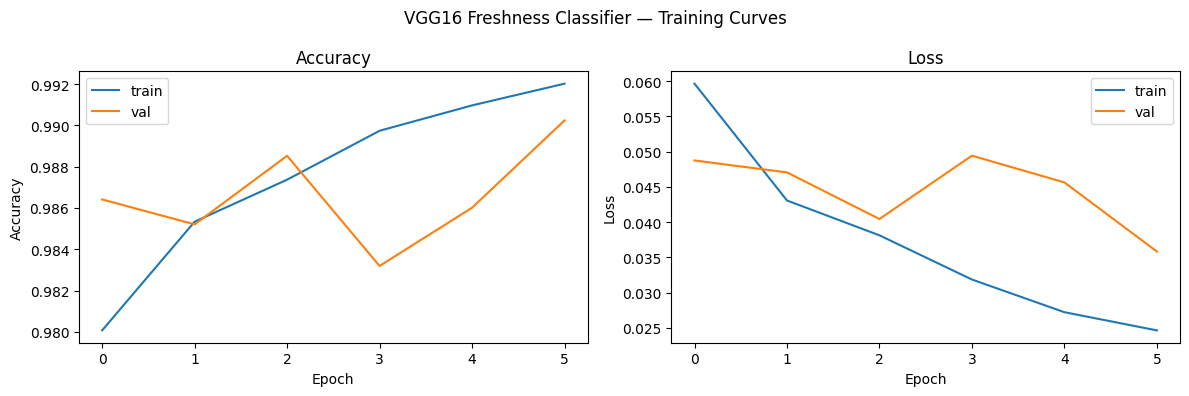

Saved: training_curves.png


In [39]:
import json
import matplotlib.pyplot as plt

# Load from memory if available, otherwise from saved JSON files
def load_history(history_obj, json_path):
    if history_obj is not None:
        return history_obj.history
    if os.path.exists(json_path):
        with open(json_path, "r") as f:
            return json.load(f)
    return None

h1 = load_history(history_stage1 if 'history_stage1' in dir() else None, HISTORY_PATH_STAGE1)
h2 = load_history(history_stage2 if 'history_stage2' in dir() else None, HISTORY_PATH_STAGE2)

if h1 is None and h2 is None:
    print("No history found — train the model first.")
else:
    acc      = (h1.get("accuracy", []) if h1 else []) + (h2.get("accuracy", []) if h2 else [])
    val_acc  = (h1.get("val_accuracy", []) if h1 else []) + (h2.get("val_accuracy", []) if h2 else [])
    loss_h   = (h1.get("loss", []) if h1 else []) + (h2.get("loss", []) if h2 else [])
    val_loss = (h1.get("val_loss", []) if h1 else []) + (h2.get("val_loss", []) if h2 else [])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(acc, label="train"); axes[0].plot(val_acc, label="val")
    axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy"); axes[0].legend()

    axes[1].plot(loss_h, label="train"); axes[1].plot(val_loss, label="val")
    axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss"); axes[1].legend()

    plt.suptitle("VGG16 Freshness Classifier — Training Curves")
    plt.tight_layout()
    plt.savefig(os.path.join(MODELS_DIR, "training_curves.png"), dpi=150)
    plt.show()
    print("Saved: training_curves.png")

## 12) Download the trained model directly (optional, alternative to Drive)

In [40]:
from google.colab import files
files.download(MODEL_OUT)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>